In [287]:
# packages
import numpy as np
import random as random
import matplotlib.pyplot as plt
import time

# ESTABLISHING INITIAL PARAMETERS

In [288]:
step = 0.05 # difference between states (discretization of our continuous problem)
max_initial = 1 # initial state is picked by random unif from 0 to (max_initial)
T = 2

gamma = 0.2 # for production function
rho = 0.95 # discounting (in production function as well)
C = 3 # for production function

supp_W = [0.9, 1.3] # given white noise process with
pmf_W = [0.75, 0.25] # specific supports and probabilities

# calculate expectation of white noise process 
exp_W_gamma = 0
for i in range(len(supp_W)):
    exp_W_gamma += np.pow(supp_W[i], gamma) * pmf_W[i]

# calculate rho * expectation [W ^ gamma]
pEWgamma = rho * exp_W_gamma

# by the production ccalculate maximum state attainable
max_growth = np.max(supp_W) * C / (pEWgamma) # maximum return on investment (assumes mu = 0
max_wealths = [round(max_initial / step)]
for t in range(T):
    max_wealths.append(round(max_wealths[t] * max_growth)) # maximum possible wealth at times

In [289]:
max = max_wealths[-2] * step + step
size = round(max / step) # size of states and actions
states = np.arange(0, max, step)
actions = np.arange(0, max, step)

reps = 10 # number of times running it 'N' episodes
N = 50000 # number of episodes
phi = 15 # soft-min parameter
om_q = 0.55 # rho_q parameter
om_mu = 0.85 # rho_mu parameter

jump = round(N / 100) # take a measurement of mu every "jump" step

num_X = len(states)
num_A = len(actions)

# white noise with two outcomes with probabilities established above
def W ():
    return np.random.choice(supp_W, p = pmf_W)


# IMPORTANT FUNCTIONS

In [296]:
# transition kernel utilizing the softmin distribution for action
def trans_kernel_dist (a, q_tab, nu, t):
    x_dist = np.zeros((max_wealths[t] + 1), dtype = float)

    for w in range(len(supp_W)):
        poss_valu = a * supp_W[w] * C / ((pEWgamma) * (1 + (C - 1) * np.pow(nu, 3)))
        x_dist[round(poss_valu)] += pmf_W[w]

    return x_dist

# update entire mean field joint distribution at once
def P_Theta_MFG (q_tab, mu_a_dist, t):
    
    # calculate mean field action as a singular value
    nu = np.dot(mu_a_dist[t], actions)
    
    # find softmax distribution for action policy for each state
    weights = []
    for x in range(max_wealths[t] + 1):
        max_q = np.max(q_tab[t][x][:x + 1])
        weights.append(np.exp(-phi * (max_q - q_tab[t][x])))
        weights[x] /= np.sum(weights[x])

    # initialize distribution that the mean field action distribution should trend towards
    target_means = np.zeros((num_A), dtype = float)

    if t == 0:

        # for initial state, state distribution never changes, so distribution is based on softmax distribution on each state
        for x in range(max_wealths[t] + 1):
            for a in range(x + 1):
                target_means[a] += weights[x][a] / ((1.0 / step) + 1.0)

    else:

        for a_prime in range(max_wealths[t - 1] + 1):
            
            x_dist = trans_kernel_dist(a_prime, q_tab, nu, t) # for each previous step action find the current step state distribution

            for x in range(max_wealths[t] + 1):

                # update target distribution, adding softmax weights, scaled by the distribution of previous action and resulting current state distribution
                target_means += x_dist[x] * mu_a_dist[t - 1][a_prime] * weights[x] 
    
    target_means = target_means / np.sum(target_means) # normalize, although running the program 21 times led to sum(mu) = ~0.97
    return target_means - mu_a_dist[t]

# defined Q table updating function
def T_2 (q_tab, mu_dist, x, a, t):
    utility = np.pow(states[x] - actions[a], gamma) / gamma
    mean_sum = 0

    # calculate mean field action as a singular value
    nu = np.dot(mu_dist[t], actions)

    for w in range(len(supp_W)):
        poss_valu = a * supp_W[w] * C / ((pEWgamma) * (1 + (C - 1) * np.pow(nu, 3)))
        if t == T - 1:
            q_val = np.pow(poss_valu, gamma) / gamma
        else:
            q_val = np.max(q_tab[t + 1][round(poss_valu)])
        mean_sum += pmf_W[w] * q_val
        
    return utility + rho * mean_sum - q_tab[t][x][a]

'''
def P_2_MFC (q_tab, mu_x_distr, mu, traj_x, traj_a, t):
    target_means = np.zeros(num_X, dtype = float)

    for x in range(num_X):
        if x == traj_x:
            a = traj_a
        else:
            a = softMinAct(q_tab[t][x], x)
        
        for w in range(len(supp_W)):
            poss_valu = a * supp_W[w] * C / ((pEWgamma) * (1 + (C - 1) * np.pow(mu, 3)))
            target_means[round(poss_valu)] += pmf_W[w] * mu_x_distr[t][x]

    return target_means - mu_x_distr[t + 1]
'''

'\ndef P_2_MFC (q_tab, mu_x_distr, mu, traj_x, traj_a, t):\n    target_means = np.zeros(num_X, dtype = float)\n\n    for x in range(num_X):\n        if x == traj_x:\n            a = traj_a\n        else:\n            a = softMinAct(q_tab[t][x], x)\n\n        for w in range(len(supp_W)):\n            poss_valu = a * supp_W[w] * C / ((pEWgamma) * (1 + (C - 1) * np.pow(mu, 3)))\n            target_means[round(poss_valu)] += pmf_W[w] * mu_x_distr[t][x]\n\n    return target_means - mu_x_distr[t + 1]\n'

### INITIALIZING Q / MU AND RUNNING IDEALIZED TWO TIMESCALE APPROACH

In [297]:
Q = np.zeros((T, num_X, num_A), dtype = float) # initialize Q function
mu = np.zeros((T, num_A), dtype = float) # mean field time-state distribution

for t in range(T):
    for x in range(max_wealths[t] + 1):
        mu[t][x] = 1.0 # initialize mu
        for a in range(x + 1):
            Q[t][x][a] = 30.0 # set Q function to (value) if state-action pair is possible (so soft-max policy explores the unexplored)
    mu[t] = mu[t] / np.sum(mu[t]) # normalize each time step distribution

tol = 0.01
SSE = 0

phi = 15
om_q = 0.55 # rho_q parameter
om_mu = 0.85 # rho_mu parameter

# while changes to mu distribution and q-table are large enough (measured by sum of squared delta),
# keep iterating through the formulas to update mu and Q
for k in range(10000):
    SSE = 0
    for t in range(T):
        mu_delta = P_Theta_MFG(Q, mu, t) / np.pow(1 + k, om_mu) # change in the distribution from function
        mu[t] += mu_delta # update distribution
        SSE += np.sum(mu_delta**2) # calculating sum of squares
        for x in range(max_wealths[t] + 1):
            for a in range(x + 1):
                Q_delta = T_2(Q, mu, x, a, t) / np.pow(1 + k, om_q) # change in q-value from function
                Q[t][x][a] += Q_delta # update q-value
                SSE += np.pow(Q_delta, 2) # calculating sum of squares
    
    print("%3d %12.4f" % (k, SSE))
    if SSE < tol:
        break

  0  734325.4549
  1   33894.9629
  2    2973.6584
  3     518.4273
  4     119.8425
  5      37.1915
  6      14.9530
  7       8.2927
  8       5.6045
  9       4.1717
 10       3.3485
 11       2.7528
 12       2.3075
 13       1.9020
 14       1.5423
 15       1.2567
 16       1.0209
 17       0.8473
 18       0.6969
 19       0.5742
 20       0.4829
 21       0.3952
 22       0.3288
 23       0.2732
 24       0.2293
 25       0.1921
 26       0.1635
 27       0.1399
 28       0.1174
 29       0.0996
 30       0.0858
 31       0.0730
 32       0.0630
 33       0.0546
 34       0.0470
 35       0.0409
 36       0.0359
 37       0.0318
 38       0.0272
 39       0.0236
 40       0.0201
 41       0.0173
 42       0.0149
 43       0.0129
 44       0.0114
 45       0.0101
 46       0.0090


# VISUALIZING OPTIMAL CONTROL

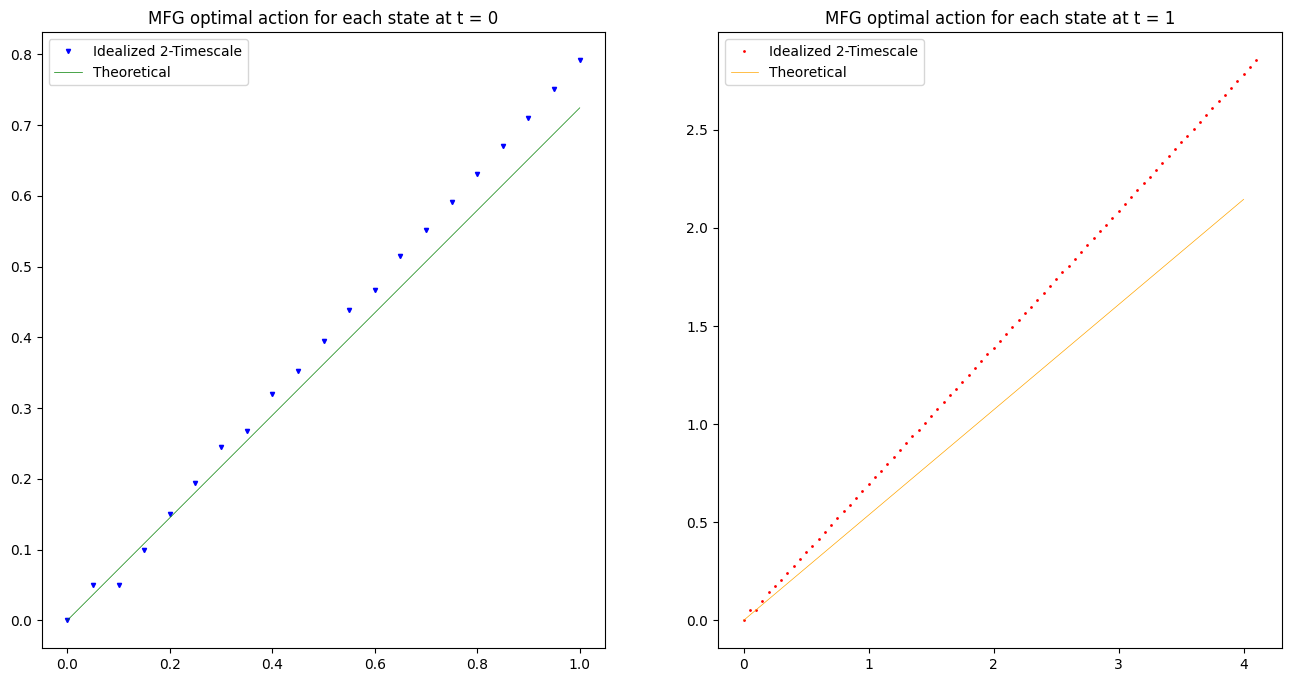

In [298]:
# utilizing the soft max distribution
# calculate the expectation of an action choice
def softMaxMean (Q_tx, x_idx):
    sum = 0
    weights = np.zeros(num_X)
    for a in range(x_idx + 1):
        weights[a] = np.exp(phi * Q_tx[a])
        sum += weights[a]
    
    weights = weights / sum
    return np.dot(weights, actions)

# iterate through each time step and state to calculate optimal policy from soft max expectation
optimIND = []
optim = []
for t in range (T):
    optim.append([])
    optimIND.append([])
    for x in range (max_wealths[t] + 1):
        optim[t].append(softMaxMean(Q[t][x], x))
        optimIND[t].append(states[x])

%matplotlib inline

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].plot(optimIND[0], optim[0], linewidth = 0, marker = 'v', markersize = 3, color = "blue")
axs[0].plot([0, 1], [0, 0.724517], linewidth = 0.5, color = "green")
axs[0].set_title("MFG optimal action for each state at t = 0")
axs[0].legend(["Idealized 2-Timescale", "Theoretical"])

axs[1].plot(optimIND[1], optim[1], linewidth = 0, marker = 'o', markersize = 1, color = "red")
axs[1].plot([0, 4], [0, 0.536292 * 4], linewidth = 0.5, color = "orange")
axs[1].set_title("MFG optimal action for each state at t = 1")
axs[1].legend(["Idealized 2-Timescale", "Theoretical"])

In [299]:
# print the mean field action distribution
print("            t = 0    t = 1")
for a in range(num_A):
    print("a = %4.2f:  %7.5f  %7.5f" % (actions[a], mu[0][a], mu[1][a]))

            t = 0    t = 1
a = 0.00:  0.00864  0.00341
a = 0.05:  0.10006  0.07919
a = 0.10:  0.05006  0.03314
a = 0.15:  0.05547  0.04286
a = 0.20:  0.05032  0.04108
a = 0.25:  0.07704  0.04012
a = 0.30:  0.04700  0.04810
a = 0.35:  0.07944  0.04599
a = 0.40:  0.04852  0.04545
a = 0.45:  0.07783  0.04473
a = 0.50:  0.05030  0.04521
a = 0.55:  0.07092  0.04360
a = 0.60:  0.05583  0.04350
a = 0.65:  0.06839  0.04349
a = 0.70:  0.05259  0.04280
a = 0.75:  0.05689  0.04190
a = 0.80:  0.03150  0.04079
a = 0.85:  0.01646  0.03905
a = 0.90:  0.00263  0.03638
a = 0.95:  0.00009  0.03272
a = 1.00:  0.00001  0.02825
a = 1.05:  0.00000  0.02341
a = 1.10:  0.00000  0.01878
a = 1.15:  0.00000  0.01476
a = 1.20:  0.00000  0.01158
a = 1.25:  0.00000  0.00929
a = 1.30:  0.00000  0.00772
a = 1.35:  0.00000  0.00662
a = 1.40:  0.00000  0.00573
a = 1.45:  0.00000  0.00491
a = 1.50:  0.00000  0.00412
a = 1.55:  0.00000  0.00336
a = 1.60:  0.00000  0.00267
a = 1.65:  0.00000  0.00206
a = 1.70:  0.00000  0

In [294]:
''' USELESS OLD FUNCTIONS
# defined mean field state distribution updating function
def P_2_MFG (q_tab, mu_x_distr, nu, t):
    target_means = np.zeros(num_X, dtype = float)

    for x in range(max_wealths[t] + 1):
        for x_prime in range(max_wealths[t + 1] + 1):
            target_means[x] += trans_kernel(x_prime, x, q_tab, nu, t) * mu_x_distr[t][x]

    return target_means - mu_x_distr[t + 1]

# defined mean field action updating function
def P_2_a (q_tab, mu_x_dist, nu, t):
    mean_action = 0
    for x in range(num_X):
        mean_action += mu_x_dist[t][x] * softMinMean(q_tab[t][x], x)
    return mean_action - nu

# update entire mean field joint distribution at once
def P_V2_MFG (q_tab, mu_dist, t):
    
    # calculate mean field action as a singular value
    nu = 0
    for x in range(max_wealths[t] + 1):
        nu += np.dot(mu_dist[t][x], actions)
    
    # find softmax distribution for action policy for each state
    weights = []
    for x in range(max_wealths[t] + 1):
        max_q = np.max(q_tab[t][x][:x + 1])
        weights.append(np.exp(-phi * (max_q - q_tab[t][x])))
        weights[x] /= np.sum(weights[x])

    # 2d array of the value of the function P_V2 indexed by each x, a
    target_means = np.zeros((num_X, num_A), dtype = float)

    if t == 0:

        # for initial state, state distribution never changes, so distribution is based on softmax distribution on each state
        for x in range(max_wealths[t] + 1):
            for a in range(x + 1):
                target_means[x][a] = weights[x][a] / ((1.0 / step) + 1.0)

    else:
        mu_a_dist = np.sum(mu_dist[t], axis = 0)
        for a_prime in range(max_wealths[t - 1] + 1):
            x_dist = trans_kernel_dist(a_prime, q_tab, nu, t) # for each previous step action find the current step state distribution
            xa_dist = []
            for x in range(max_wealths[t] + 1):
                xa_dist.append(x_dist[x] * weights[x]) # for each current state scale the softmax distribution by state distribution
            
            # multiply the calculated joint distribution from this specific action by the mean field marginal total by action
            target_means += np.multiply(mu_a_dist[a_prime], xa_dist)
    
    target_means = target_means / np.sum(target_means)
    return target_means - mu_dist[t]

# transition kernel utilizing the softmin distribution for action
def trans_kernel (x_prime, x, q_tab, nu, t):
    prob = 0

    q = q_tab[t][x][:x + 1]
    max_q = np.max(q)

    weights = np.exp(-phi * (max_q - q))
    weights /= weights.sum()

    for a in range(x + 1):
        for w in range(len(supp_W)):
            poss_valu = a * supp_W[w] * C / ((pEWgamma) * (1 + (C - 1) * np.pow(nu, 3)))
            if round(poss_valu) == x_prime:
                prob += weights[a] * pmf_W[w]

    return prob

# get the expectation of the soft min distribution
# essentially a softmax, but we take the maximum and offset all values by that constant
def softMinMean (Q_x, x_idx):
    q = Q_x[:x_idx + 1]
    max_q = np.max(q)

    weights = np.exp(-phi * (max_q - q))
    weights /= weights.sum()
    return np.dot(np.linspace(0, step * x_idx, x_idx + 1), weights)
'''

' USELESS OLD FUNCTIONS\n# defined mean field state distribution updating function\ndef P_2_MFG (q_tab, mu_x_distr, nu, t):\n    target_means = np.zeros(num_X, dtype = float)\n\n    for x in range(max_wealths[t] + 1):\n        for x_prime in range(max_wealths[t + 1] + 1):\n            target_means[x] += trans_kernel(x_prime, x, q_tab, nu, t) * mu_x_distr[t][x]\n\n    return target_means - mu_x_distr[t + 1]\n\n# defined mean field action updating function\ndef P_2_a (q_tab, mu_x_dist, nu, t):\n    mean_action = 0\n    for x in range(num_X):\n        mean_action += mu_x_dist[t][x] * softMinMean(q_tab[t][x], x)\n    return mean_action - nu\n\n# update entire mean field joint distribution at once\ndef P_V2_MFG (q_tab, mu_dist, t):\n\n    # calculate mean field action as a singular value\n    nu = 0\n    for x in range(max_wealths[t] + 1):\n        nu += np.dot(mu_dist[t][x], actions)\n\n    # find softmax distribution for action policy for each state\n    weights = []\n    for x in range(m

In [295]:
'''
Q = np.zeros((T, num_X, num_A), dtype = float) # unified Q function
mu_x = np.zeros([num_X, num_A, T,  num_X], dtype = float) # separate mean field for each trajectory

for t in range(T):
    for x in range(max_wealths[t] + 1):
        for a in range(x + 1):
            Q[t][x][a] = 30.0 # set Q function to (value) if state-action pair is possible (so soft-max policy explores the unexplored)

for x in range(num_X):
    for a in range(x + 1):
        for t in range(T):
            for x_prime in range(max_wealths[t]):
                mu_x[x][a][t][x_prime] = 1.0
            mu_x[x][a][t] = mu_x[x][a][t] / (max_wealths[t] + 1)

tol = 0.01
SSE = 0
count = 1

for n in range(100000):
    SSE = 0
    for t in range(T - 1, -1, -1):
        for x in range(num_X):
            for a in range(x + 1):
                mu = getMu(Q, mu_x[x][a], t)
                mu_delta = P_2_MFC(Q, mu_x[x][a], mu, x, a, t) / count
                Q_delta = T_2(Q, mu, x, a, t) / np.pow(count, 2)
                mu[x][a][t] += mu_delta
                Q[t][x][a] += Q_delta
                SSE += np.pow(Q_delta, 2)
                SSE += np.sum(mu_delta**2)
    
    if SSE < 1:
        print(n)
        break
    count += 1
'''

'\nQ = np.zeros((T, num_X, num_A), dtype = float) # unified Q function\nmu_x = np.zeros([num_X, num_A, T,  num_X], dtype = float) # separate mean field for each trajectory\n\nfor t in range(T):\n    for x in range(max_wealths[t] + 1):\n        for a in range(x + 1):\n            Q[t][x][a] = 30.0 # set Q function to (value) if state-action pair is possible (so soft-max policy explores the unexplored)\n\nfor x in range(num_X):\n    for a in range(x + 1):\n        for t in range(T):\n            for x_prime in range(max_wealths[t]):\n                mu_x[x][a][t][x_prime] = 1.0\n            mu_x[x][a][t] = mu_x[x][a][t] / (max_wealths[t] + 1)\n\ntol = 0.01\nSSE = 0\ncount = 1\n\nfor n in range(100000):\n    SSE = 0\n    for t in range(T - 1, -1, -1):\n        for x in range(num_X):\n            for a in range(x + 1):\n                mu = getMu(Q, mu_x[x][a], t)\n                mu_delta = P_2_MFC(Q, mu_x[x][a], mu, x, a, t) / count\n                Q_delta = T_2(Q, mu, x, a, t) / np.pow